In [7]:
import pandas as pd
import os
from dotenv import load_dotenv
import snowflake.connector
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.model_selection import GridSearchCV


load_dotenv("snowflake.env")

conn = snowflake.connector.connect(
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA"),
)

df = pd.read_sql("SELECT * FROM HEART_RAW;", conn)
df.head()


/var/folders/m7/y62frbxs2bdgjf57r0qqmk440000gn/T/ipykernel_10006/3786665455.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM HEART_RAW;", conn)


,TS,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,1764639616245,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,1764639617245,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,1764639618245,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,1764639619245,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,1764639620245,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


age – idade

sex – sexo

chest pain type (4 values) – tipo de dor no peito (4 valores)

resting blood pressure – pressão arterial em repouso

serum cholesterol in mg/dl – colesterol sérico em mg/dl (quantidade de colesterol presente no soro do sangue)

fasting blood sugar > 120 mg/dl – glicemia em jejum > 120 mg/dl

resting electrocardiographic results (values 0,1,2) – resultados do eletrocardiograma em repouso (valores 0,1,2)

maximum heart rate achieved – frequência cardíaca máxima alcançada

exercise induced angina – angina(dor ou desconforto no peito) induzida por exercício

oldpeak = ST depression induced by exercise relative to rest – oldpeak = depressão do segmento ST induzida por exercício em relação ao repouso

the slope of the peak exercise ST segment – inclinação do segmento ST no pico do exercício

number of major vessels (0-3) colored by fluoroscopy – número de vasos principais (0-3) coloridos por fluoroscopia

thal: 0 = normal; 1 = fixed defect; 2 = reversible defect – thal: 0 = normal; 1 = defeito fixo; 2 = defeito reversível (fluxo de sangue que chega ao músculo cardíaco (miocárdio)

In [8]:
df.columns

Index(['TS', 'AGE', 'SEX', 'CP', 'TRESTBPS', 'CHOL', 'FBS', 'RESTECG',
       'THALACH', 'EXANG', 'OLDPEAK', 'SLOPE', 'CA', 'THAL', 'TARGET'],
      dtype='object')

In [9]:
df = df.drop(columns=['TS'])

In [10]:
df.columns

Index(['AGE', 'SEX', 'CP', 'TRESTBPS', 'CHOL', 'FBS', 'RESTECG', 'THALACH',
       'EXANG', 'OLDPEAK', 'SLOPE', 'CA', 'THAL', 'TARGET'],
      dtype='object')

Step 1 — Análise estatística descritiva
Neste passo realizamos a etapa de Understanding the Dataset, tal como descrito no artigo. Calculamos estatísticas descritivas (média, mediana, desvio padrão, valores mínimo e máximo) para as variáveis numéricas e analisamos a distribuição das variáveis categóricas. Essa visão inicial serve para entender o perfil da base e apoiar as decisões de limpeza, principalmente em atributos clínicos sensíveis como pressão arterial, colesterol e medidas relacionadas ao esforço.

In [52]:
NUMERIC_COLS = ['AGE', 'TRESTBPS', 'CHOL', 'THALACH', 'OLDPEAK']
CATEGORICAL_COLS = ['SEX', 'CP', 'FBS', 'RESTECG', 'EXANG', 'SLOPE', 'CA', 'THAL']

print("ESTATÍSTICAS DAS COLUNAS NUMÉRICAS:")
display(df[NUMERIC_COLS].describe())

print("\nDISTRIBUIÇÃO DAS COLUNAS CATEGÓRICAS:")
for COL in CATEGORICAL_COLS:
    print(f"\n{COL}:")
    print(df[COL].value_counts())





ESTATÍSTICAS DAS COLUNAS NUMÉRICAS:


,AGE,TRESTBPS,CHOL,THALACH,OLDPEAK
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512
std,9.072290,17.516718,51.59251,23.005724,1.175053
min,29.000000,94.000000,126.00000,71.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000
75%,61.000000,140.000000,275.00000,166.000000,1.800000
max,77.000000,200.000000,564.00000,202.000000,6.200000



DISTRIBUIÇÃO DAS COLUNAS CATEGÓRICAS:

SEX:
SEX
1    713
0    312
Name: count, dtype: int64

CP:
CP
0    497
2    284
1    167
3     77
Name: count, dtype: int64

FBS:
FBS
0    872
1    153
Name: count, dtype: int64

RESTECG:
RESTECG
1    513
0    497
2     15
Name: count, dtype: int64

EXANG:
EXANG
0    680
1    345
Name: count, dtype: int64

SLOPE:
SLOPE
1    482
2    469
0     74
Name: count, dtype: int64

CA:
CA
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64

THAL:
THAL
2    544
3    410
1     64
0      7
Name: count, dtype: int64


Step 2 — Identificação visual de outliers.
Embora o artigo tenha utilizado stripplots para inspecionar visualmente outliers em algumas variáveis específicas, optamos por utilizar boxplots em todas as variáveis numéricas, para ter uma identificação mais clara e objetiva de valores outliers.

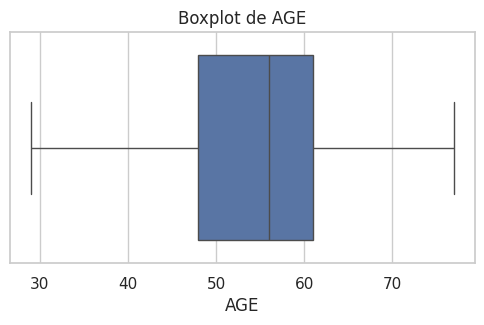

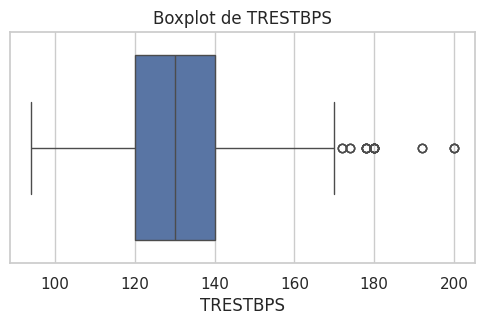

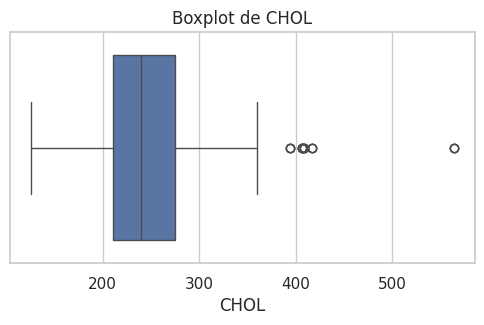

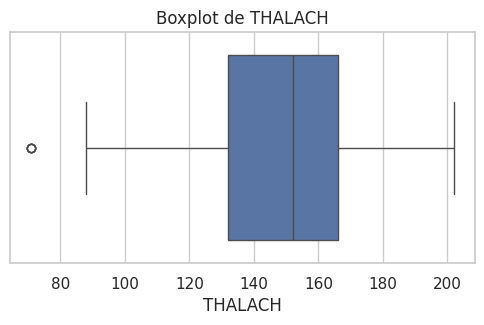

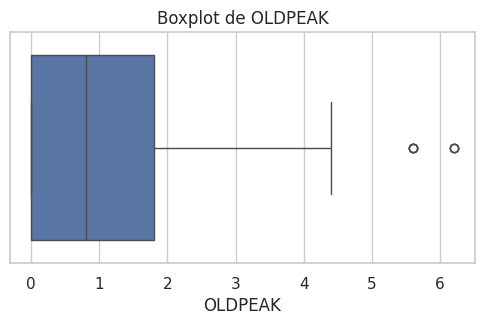

In [53]:
cols = ['AGE', 'TRESTBPS', 'CHOL', 'THALACH', 'OLDPEAK']


for c in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(data=df, x=c)
    plt.title(f"Boxplot de {c}")
    plt.show()

Como observado nos boxplots, algumas variáveis numéricas apresentam outliers. Porém, apenas a coluna de colesterol (CHOL) possui um outlier realmente extremo. Por esse motivo, apenas o registro significativamente distante dos demais será removido do conjunto de dados.

In [54]:
df[df["CHOL"] > 500]

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
192,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
464,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1


In [137]:
df = df[df["CHOL"] <= 500]

In [74]:
df[df["CHOL"] > 500]

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET


Conferindo se existem valores nulos

In [44]:
df.isnull().sum()

AGE         0
SEX         0
CP          0
TRESTBPS    0
CHOL        0
FBS         0
RESTECG     0
THALACH     0
EXANG       0
OLDPEAK     0
SLOPE       0
CA          0
THAL        0
TARGET      0
dtype: int64

Conferindo valores duplicados

In [45]:
df.shape

(1022, 14)

In [138]:
df = df.drop_duplicates()


In [47]:
df.shape

(301, 14)

Step 3 - Visualização dos dados.
Assim como no artigo, alguns gráficos foram produzidos para facilitar a exploração inicial do conjunto de dados e identificar padrões relevantes. Foram gerados os gráficos mostrados no estudo, com a variável-alvo, como Age × Target, RestingBP × Target, Cholesterol × Age e a distribuição dos tipos de dor no peito (Chest Pain Type).

Além desses, também incluímos visualizações complementares. A relação entre Chest Pain Type e a pressão arterial de repouso (RestingBP), que ajuda a observar se determinados tipos de dor no peito estão associados a níveis diferentes de pressão. Também foi adicionada a comparação entre sexo e colesterol, permitindo identificar possíveis diferenças entre homens e mulheres nos níveis de colesterol. 9.
VOLU

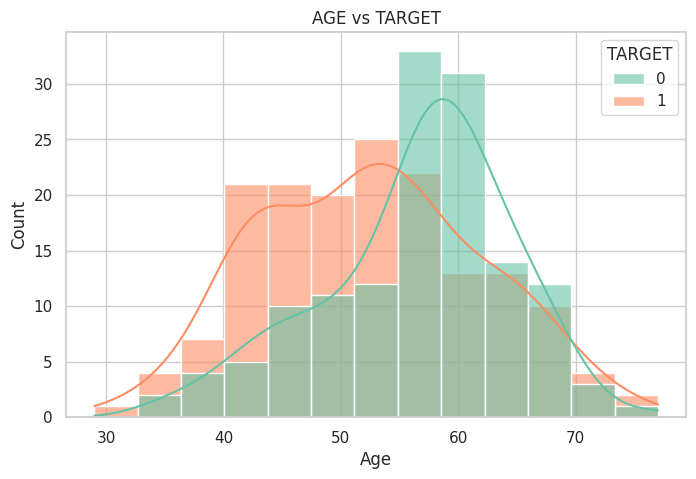

In [59]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="AGE",
    hue="TARGET",
    kde=True,
    stat="count",
    common_norm=False,
    palette="Set2",
    alpha=0.6
)

plt.title("AGE vs TARGET")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


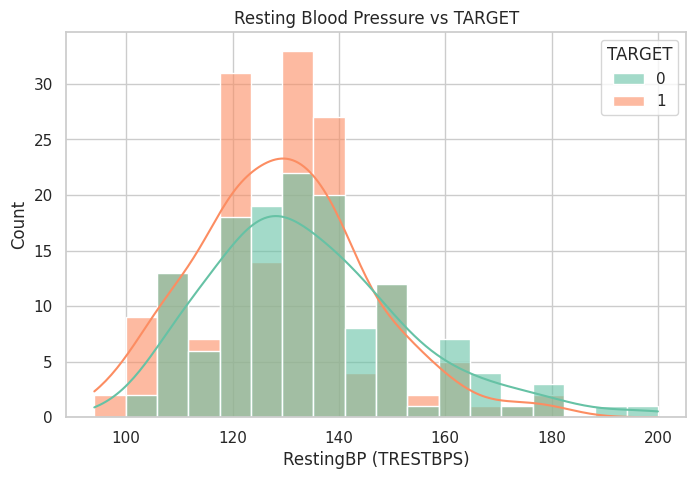

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="TRESTBPS",
    hue="TARGET",
    kde=True,
    stat="count",
    common_norm=False,
    palette="Set2",
    alpha=0.6
)
plt.title("Resting Blood Pressure vs TARGET")
plt.xlabel("RestingBP (TRESTBPS)")
plt.ylabel("Count")
plt.show()


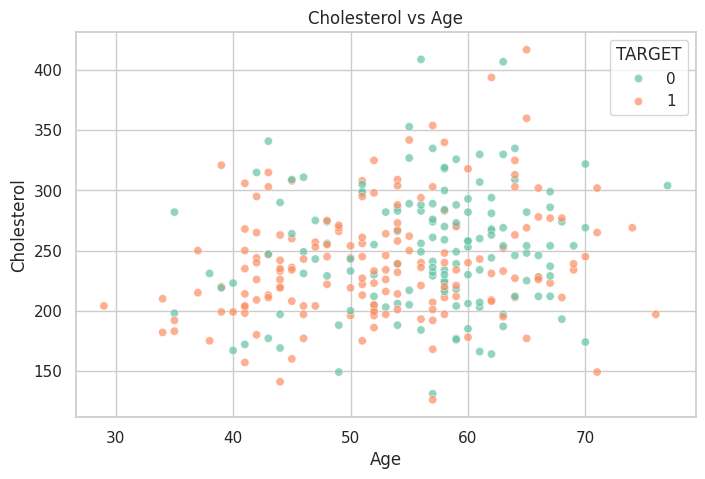

In [61]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="AGE",
    y="CHOL",
    hue="TARGET",
    palette="Set2",
    alpha=0.7
)
plt.title("Cholesterol vs Age")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

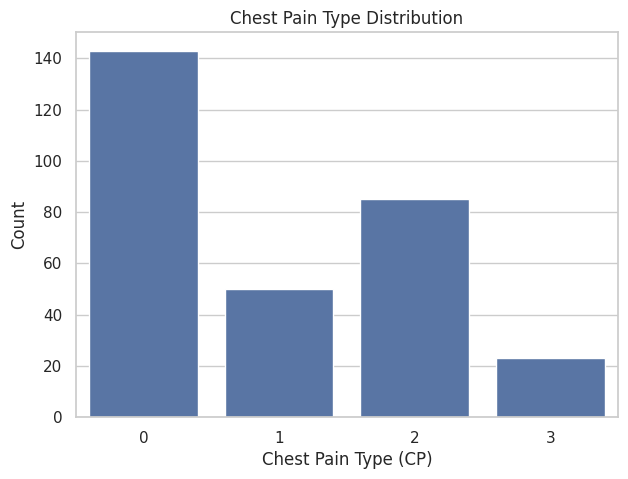

In [63]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="CP",
)
plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type (CP)")
plt.ylabel("Count")
plt.show()


/tmp/ipykernel_210/1022777678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


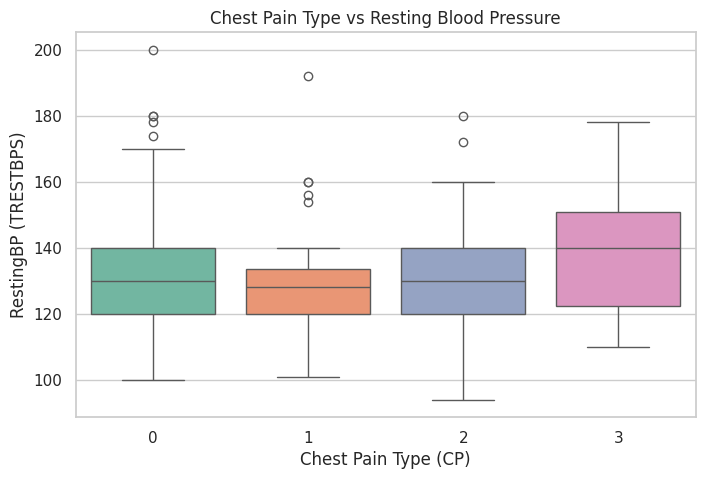

In [66]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="CP",
    y="TRESTBPS",
    palette="Set2"
)
plt.title("Chest Pain Type vs Resting Blood Pressure")
plt.xlabel("Chest Pain Type (CP)")
plt.ylabel("RestingBP (TRESTBPS)")
plt.show()

/tmp/ipykernel_210/2294670684.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


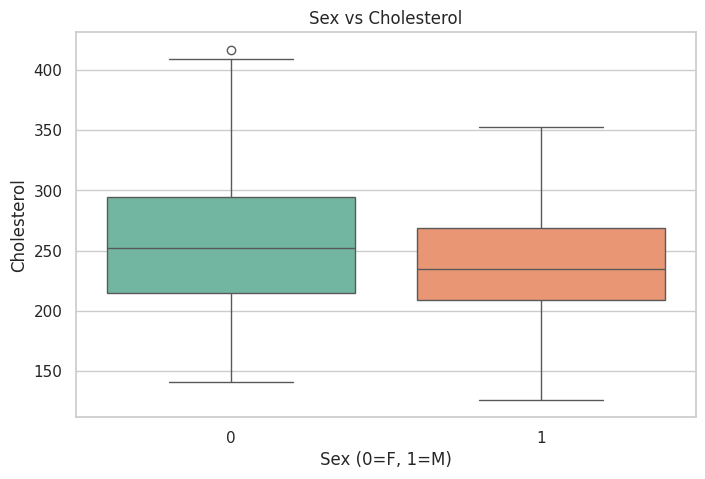

In [67]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="SEX",
    y="CHOL",
    palette="Set2"
)
plt.title("Sex vs Cholesterol")
plt.xlabel("Sex (0=F, 1=M)")
plt.ylabel("Cholesterol")
plt.show()

/tmp/ipykernel_210/4107347218.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


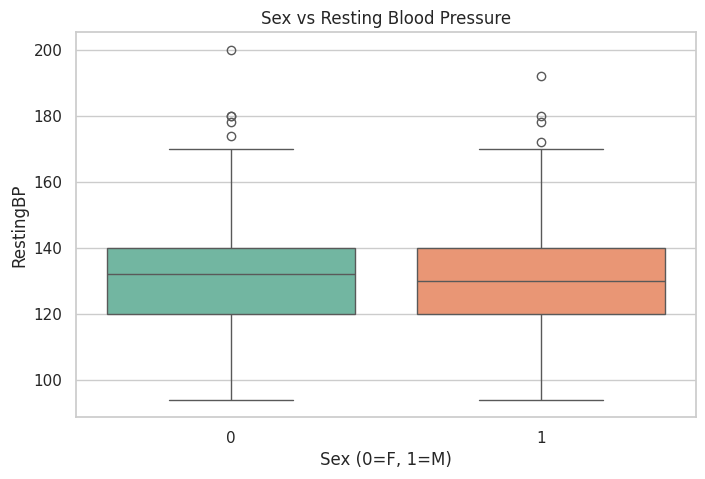

In [68]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="SEX",
    y="TRESTBPS",
    palette="Set2"
)
plt.title("Sex vs Resting Blood Pressure")
plt.xlabel("Sex (0=F, 1=M)")
plt.ylabel("RestingBP")
plt.show()

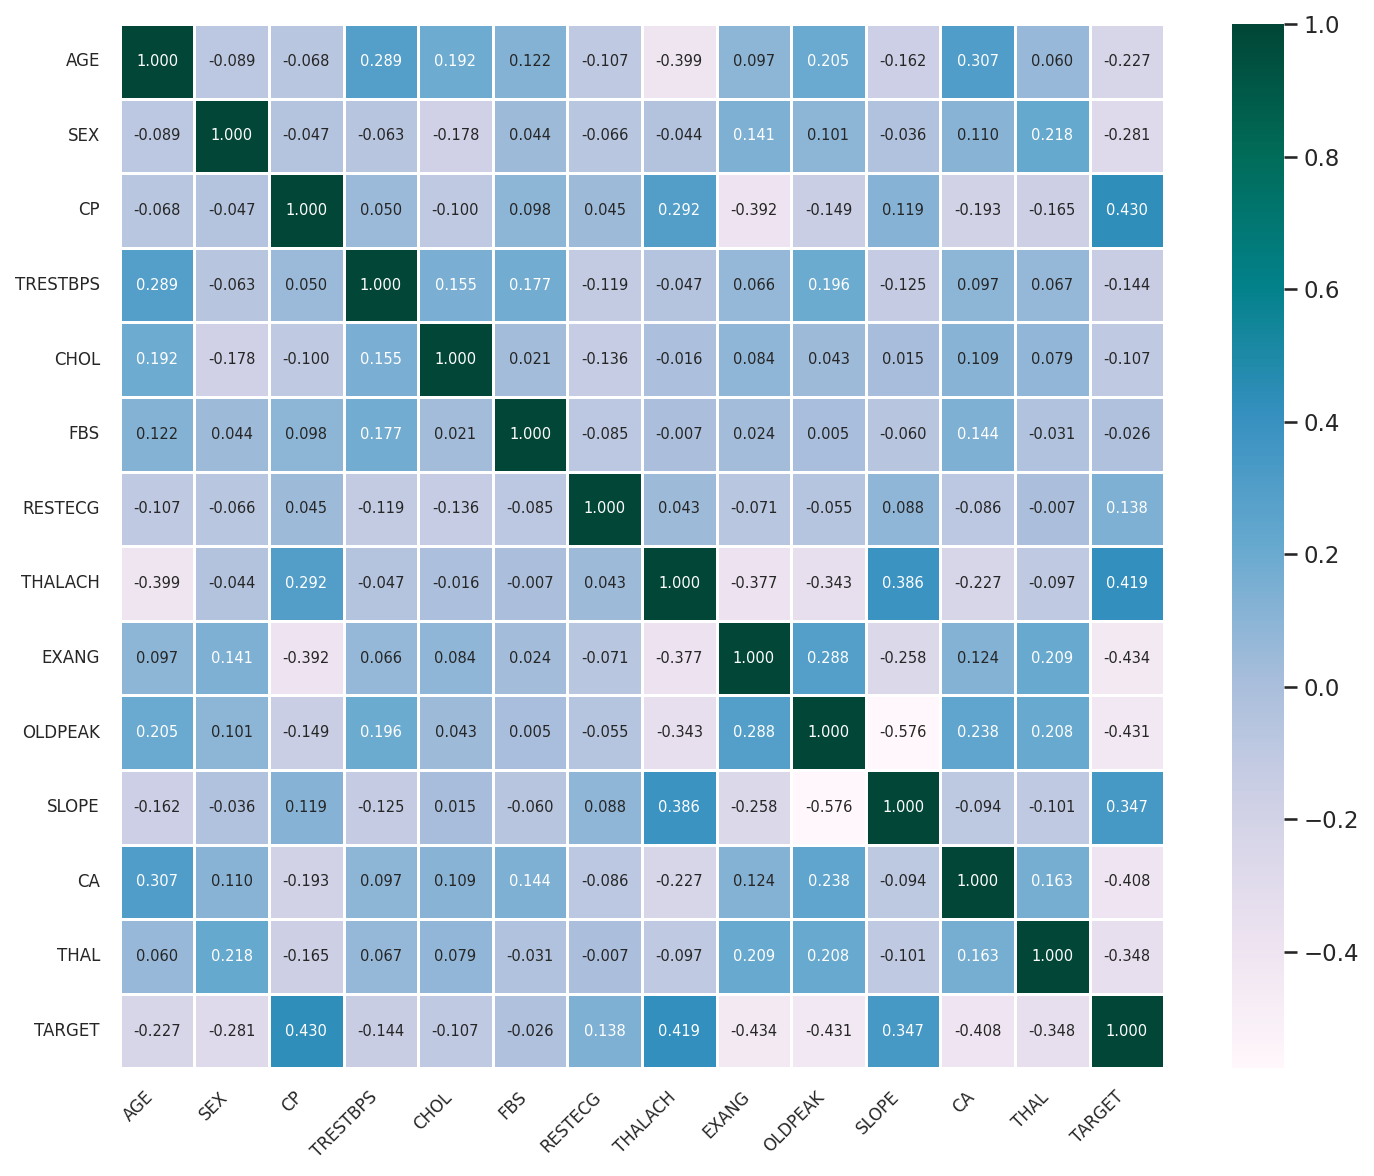

In [83]:

plt.figure(figsize=(10, 8), dpi=150)

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".3f",
    cmap="PuBuGn",       
    linewidths=0.5,
    square=True,
    cbar=True,
    annot_kws={"size": 7}  
)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()



A análise exploratória revela que, neste conjunto de dados, a maior concentração de pessoas com doença cardíaca está entre 40 e 55 anos, enquanto indivíduos acima de 55 aparecem com mais frequência no grupo sem a doença. A pressão arterial de repouso entre 120 e 140 mmHg é mais comum entre aqueles com diagnóstico positivo, embora os valores dos demais pacientes sejam mais distribuídos. O colesterol não apresenta um padrão claro em relação à idade ou ao TARGET, apenas mostrando maior dispersão conforme a idade aumenta.

Quanto ao tipo de dor no peito, a maioria dos pacientes é assintomática (CP = 0), e indivíduos com CP = 3 tendem a apresentar pressões um pouco maisdíacos. Observa-se também que mulheres têm níveis de colesterol mais elevados que homens, enquanto a pressão arterial de repouso é bastante semelhante entre os dois nálise.


Step 4 — Codificação das variáveis categóricas
O conjunto de dados já disponibiliza todas as variáveis categóricas representadas como inteiros e floats (por exemplo: SEX, CP, FBS, RESTECG, EXANG, OLDPEAK, SLOPE, CA, THAL).

In [69]:
df.dtypes


AGE           int64
SEX           int64
CP            int64
TRESTBPS      int64
CHOL          int64
FBS           int64
RESTECG       int64
THALACH       int64
EXANG         int64
OLDPEAK     float64
SLOPE         int64
CA            int64
THAL          int64
TARGET        int64
dtype: object

Step 5 - Normalização e Divisão dos dados
No artigo original, os autores utilizaram o StandardScaler, essa escolha foi adequada porque, após o processo de limpeza, praticamente todos os outliers haviam sido removidos, tornando a distribuição das variáveis mais próxima do ideal para esse tipo de escala.

No nosso caso, embora também tenhamos tratado os outliers, optamos por manter alguns valores que não apresentaram impacto significativo na distribuição geral. Ainda assim, a presença de pequenas assimetrias motivou a realização de uma comparação entre dois métodos de normalização:

StandardScaler → mais indicado quando as variáveis possuem distribuição aproximadamente normal e poucos outliers.

RobustScaler → mais resistente a outliers, pois utiliza mediana e intervalo interquartil.

A ideia é testar ambos os métodos para verificar qual deles oferece melhor desempenho nos modelos de machine learning utilizados posteriormente.

Além disso, seguindo a metodologia do artigo, realizamos a divisão do conjunto de dados em 70% para treino e 30% para teste. Essa separação permite treinar os modelos de forma consistente e avaliar seu desempenho com dados não vistos.

In [139]:
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [141]:
X_train_standard = X_train.copy()
X_test_standard = X_test.copy()

X_train_robust = X_train.copy()
X_test_robust = X_test.copy()

In [142]:
scaler_standard = StandardScaler()

X_train_standard = scaler_standard.fit_transform(X_train_standard)
X_test_standard = scaler_standard.transform(X_test_standard)

In [143]:
scaler_robust = RobustScaler()

X_train_robust = scaler_robust.fit_transform(X_train_robust)
X_test_robust = scaler_robust.transform(X_test_robust)


Step 7 — Treinamento dos modelos base

Nesta etapa treinamos vários classificadores clássicos (Regressão Logística, Árvore de Decisão, Random Forest, SVM, Naive Bayes e KNN padrão) para obter um baseline de desempenho. Essa comparação é importante para justificar a escolha do KNN como modelo a ser otimizado, assim como feito no artigo.

In [144]:
DATASETS = {
    "STANDARD": (X_train_standard, X_test_standard),
    "ROBUST": (X_train_robust, X_test_robust)
}

In [145]:
print(X_train_standard.shape, X_test_standard.shape)
print(X_train_robust.shape, X_test_robust.shape)


(210, 13) (91, 13)
(210, 13) (91, 13)



=========== TESTANDO MODELOS COM STANDARD SCALER ===========

--- LOGISTIC_REGRESSION (STANDARD) ---
Accuracy:      0.8131868131868132
Precision:     0.82
Recall:        0.8367346938775511
Specificity:   0.7857142857142857
F1 Score:      0.8282828282828283
AUC:           0.8858114674441205



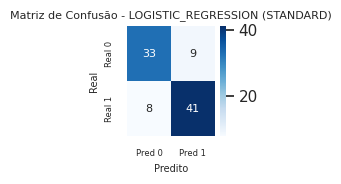

--- DECISION_TREE (STANDARD) ---
Accuracy:      0.7582417582417582
Precision:     0.813953488372093
Recall:        0.7142857142857143
Specificity:   0.8095238095238095
F1 Score:      0.7608695652173914
AUC:           0.761904761904762



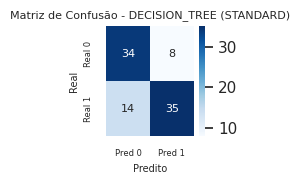

--- RANDOM_FOREST (STANDARD) ---
Accuracy:      0.7912087912087912
Precision:     0.8125
Recall:        0.7959183673469388
Specificity:   0.7857142857142857
F1 Score:      0.8041237113402062
AUC:           0.8568999028182701



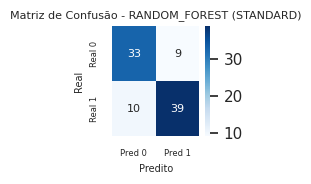

--- SVM (STANDARD) ---
Accuracy:      0.7692307692307693
Precision:     0.78
Recall:        0.7959183673469388
Specificity:   0.7380952380952381
F1 Score:      0.7878787878787878
AUC:           0.8474246841593781



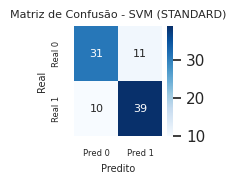

--- NAIVE_BAYES (STANDARD) ---
Accuracy:      0.8351648351648352
Precision:     0.8541666666666666
Recall:        0.8367346938775511
Specificity:   0.8333333333333334
F1 Score:      0.845360824742268
AUC:           0.8814382896015549



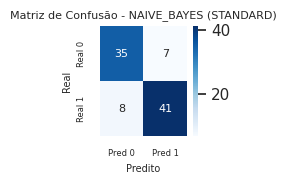

--- KNN_DEFAULT (STANDARD) ---
Accuracy:      0.7912087912087912
Precision:     0.7884615384615384
Recall:        0.8367346938775511
Specificity:   0.7380952380952381
F1 Score:      0.8118811881188119
AUC:           0.84645286686103



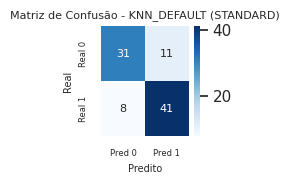


=========== TESTANDO MODELOS COM ROBUST SCALER ===========

--- LOGISTIC_REGRESSION (ROBUST) ---
Accuracy:      0.8131868131868132
Precision:     0.82
Recall:        0.8367346938775511
Specificity:   0.7857142857142857
F1 Score:      0.8282828282828283
AUC:           0.8877551020408163



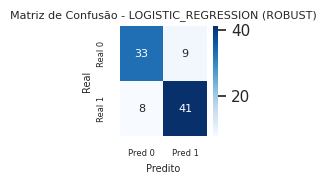

--- DECISION_TREE (ROBUST) ---
Accuracy:      0.7582417582417582
Precision:     0.813953488372093
Recall:        0.7142857142857143
Specificity:   0.8095238095238095
F1 Score:      0.7608695652173914
AUC:           0.761904761904762



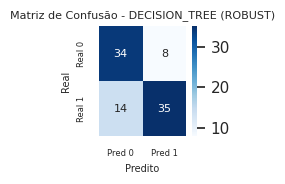

--- RANDOM_FOREST (ROBUST) ---
Accuracy:      0.7912087912087912
Precision:     0.8125
Recall:        0.7959183673469388
Specificity:   0.7857142857142857
F1 Score:      0.8041237113402062
AUC:           0.858600583090379



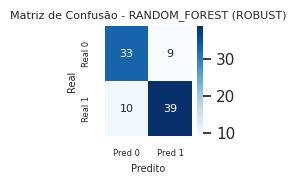

--- SVM (ROBUST) ---
Accuracy:      0.7912087912087912
Precision:     0.8
Recall:        0.8163265306122449
Specificity:   0.7619047619047619
F1 Score:      0.8080808080808081
AUC:           0.8673469387755103



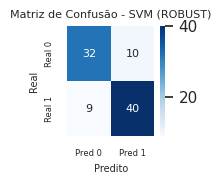

--- NAIVE_BAYES (ROBUST) ---
Accuracy:      0.8351648351648352
Precision:     0.8541666666666666
Recall:        0.8367346938775511
Specificity:   0.8333333333333334
F1 Score:      0.845360824742268
AUC:           0.8814382896015549



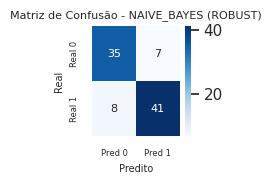

--- KNN_DEFAULT (ROBUST) ---
Accuracy:      0.7912087912087912
Precision:     0.7884615384615384
Recall:        0.8367346938775511
Specificity:   0.7380952380952381
F1 Score:      0.8118811881188119
AUC:           0.858600583090379



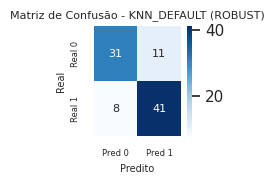

,SCALER,MODELO,ACCURACY,PRECISION,RECALL,SPECIFICITY,F1,AUC,CONF_MATRIX
0,STANDARD,LOGISTIC_REGRESSION,0.813187,0.820000,0.836735,0.785714,0.828283,0.885811,"[[33, 9], [8, 41]]"
1,STANDARD,DECISION_TREE,0.758242,0.813953,0.714286,0.809524,0.760870,0.761905,"[[34, 8], [14, 35]]"
2,STANDARD,RANDOM_FOREST,0.791209,0.812500,0.795918,0.785714,0.804124,0.856900,"[[33, 9], [10, 39]]"
3,STANDARD,SVM,0.769231,0.780000,0.795918,0.738095,0.787879,0.847425,"[[31, 11], [10, 39]]"
4,STANDARD,NAIVE_BAYES,0.835165,0.854167,0.836735,0.833333,0.845361,0.881438,"[[35, 7], [8, 41]]"
5,STANDARD,KNN_DEFAULT,0.791209,0.788462,0.836735,0.738095,0.811881,0.846453,"[[31, 11], [8, 41]]"
6,ROBUST,LOGISTIC_REGRESSION,0.813187,0.820000,0.836735,0.785714,0.828283,0.887755,"[[33, 9], [8, 41]]"
7,ROBUST,DECISION_TREE,0.758242,0.813953,0.714286,0.809524,0.760870,0.761905,"[[34, 8], [14, 35]]"
8,ROBUST,RANDOM_FOREST,0.791209,0.812500,0.795918,0.785714,0.804124,0.858601,"[[33, 9], [10, 39]]"
9,ROBUST,SVM,0.791209,0.800000,0.816327,0.761905,0.808081,0.867347,"[[32, 10], [9, 40]]"


In [146]:
MODELS = {
    "LOGISTIC_REGRESSION": LogisticRegression(max_iter=1000),
    "DECISION_TREE": DecisionTreeClassifier(random_state=42),
    "RANDOM_FOREST": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "NAIVE_BAYES": GaussianNB(),
    "KNN_DEFAULT": KNeighborsClassifier()
}

BASELINE_RESULTS = []

for SCALER_NAME, (X_TRAIN_SCALED, X_TEST_SCALED) in DATASETS.items():
    print(f"\n=========== TESTANDO MODELOS COM {SCALER_NAME} SCALER ===========\n")

    for NAME, MODEL in MODELS.items():

        MODEL.fit(X_TRAIN_SCALED, y_train)
        y_pred = MODEL.predict(X_TEST_SCALED)

        # probabilidades (necessário para AUC)
        try:
            y_prob = MODEL.predict_proba(X_TEST_SCALED)[:, 1]
        except:
            y_prob = None

        cm = confusion_matrix(y_test, y_pred)
        TN, FP, FN, TP = cm.ravel()

        # Métricas
        ACC  = accuracy_score(y_test, y_pred)
        PREC = precision_score(y_test, y_pred)
        REC  = recall_score(y_test, y_pred)              
        SPEC = TN / (TN + FP)                           
        F1   = f1_score(y_test, y_pred)
        AUC  = roc_auc_score(y_test, y_prob) if y_prob is not None else None

        BASELINE_RESULTS.append({
            "SCALER": SCALER_NAME,
            "MODELO": NAME,
            "ACCURACY": ACC,
            "PRECISION": PREC,
            "RECALL": REC,
            "SPECIFICITY": SPEC,
            "F1": F1,
            "AUC": AUC,
            "CONF_MATRIX": cm
        })

        print(f"--- {NAME} ({SCALER_NAME}) ---")
        print("Accuracy:     ", ACC)
        print("Precision:    ", PREC)
        print("Recall:       ", REC)
        print("Specificity:  ", SPEC)
        print("F1 Score:     ", F1)
        print("AUC:          ", AUC)
        print()

        plt.figure(figsize=(2, 2))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Real 0", "Real 1"],
            annot_kws={"size": 8}
        )
        
        plt.title(f"Matriz de Confusão - {NAME} ({SCALER_NAME})", fontsize=8)
        plt.xlabel("Predito", fontsize=7)
        plt.ylabel("Real", fontsize=7)
        
        plt.xticks(fontsize=6)
        plt.yticks(fontsize=6)
        
        plt.tight_layout()
        plt.show()


pd.DataFrame(BASELINE_RESULTS)


A avaliação dos modelos foi feita utilizando duas técnicas de normalização como visto anteriormente, o StandardScaler e RobustScaler, para verificar se a escala dos dados afetaria o desempenho dos classificadores. As métricas calculadas incluíram acurácia, precisão, recall, especificidade, F1-score, AUC e matriz de confusão, presentes no artigo. Os resultados mostraram que não houve diferença significativa entre os dois métodos de escalonamento, indicando que o conjunto de dados não possui outliers graves capazes de impactar os modelos.

Entre os algoritmos testados, o Naive Bayes apresentou o melhor desempenho geral em ambas as normalizações, com alta acurácia (0.83), recall elevado (0.84), boa especificidade (0.83) e AUC de aproximadamente 0.88. Esses resultados mostram que o modelo identifica bem os pacientes de maior risco, mantendo também baixo número de falsos positivos. A matriz de confusão confirmou que ele produziu o menor número de falsos negativos entre todos os classificadores avaliados.

Step 8 - Otimização de hiperparâmetros

Optamos por otimizar o KNN para seguir de acordo com o artigo e o Naive Bayes e o Logistic Regression que foram os melhores no nosso modelo

In [153]:
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": auc,
        "conf_matrix": confusion_matrix(y_test, y_pred)
    }

pipe_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])


pipe_nb.fit(X_train, y_train)
pipe_knn.fit(X_train, y_train)
pipe_lr.fit(X_train, y_train)

metrics_nb_before = get_metrics(pipe_nb, X_test, y_test)
metrics_knn_before = get_metrics(pipe_knn, X_test, y_test)
metrics_lr_before = get_metrics(pipe_lr, X_test, y_test)


#Naive Bayes
param_nb = {
    "model__var_smoothing": np.logspace(-12, -6, 20)
}

grid_nb = GridSearchCV(pipe_nb, param_nb, cv=5, scoring="f1")
grid_nb.fit(X_train, y_train)
best_nb = grid_nb.best_estimator_

#KNN
param_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan", "minkowski"]
}

grid_knn = GridSearchCV(pipe_knn, param_knn, cv=5, scoring="f1")
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_


# Logistc Regression
param_lr = {
    "model__C": np.logspace(-3, 3, 10),
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

grid_lr = GridSearchCV(pipe_lr, param_lr, cv=5, scoring="f1")
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_


#Depois do tunning
metrics_nb_after = get_metrics(best_nb, X_test, y_test)
metrics_knn_after = get_metrics(best_knn, X_test, y_test)
metrics_lr_after = get_metrics(best_lr, X_test, y_test)

df_results = pd.DataFrame([
    {"Modelo": "Naive Bayes", "Versão": "Antes",  **{k: v for k, v in metrics_nb_before.items() if k != "conf_matrix"}},
    {"Modelo": "Naive Bayes", "Versão": "Depois", **{k: v for k, v in metrics_nb_after.items()  if k != "conf_matrix"}},

    {"Modelo": "KNN", "Versão": "Antes",  **{k: v for k, v in metrics_knn_before.items() if k != "conf_matrix"}},
    {"Modelo": "KNN", "Versão": "Depois", **{k: v for k, v in metrics_knn_after.items()  if k != "conf_matrix"}},

    {"Modelo": "Logistic Regression", "Versão": "Antes",  **{k: v for k, v in metrics_lr_before.items() if k != "conf_matrix"}},
    {"Modelo": "Logistic Regression", "Versão": "Depois", **{k: v for k, v in metrics_lr_after.items()  if k != "conf_matrix"}},
])


print("Resultados")
print(df_results)

print("\nMATRIZ DE CONFUSÃO NB (ANTES)")
print(metrics_nb_before["conf_matrix"])

print("\nMATRIZ DE CONFUSÃO NB (DEPOIS)")
print(metrics_nb_after["conf_matrix"])

print("\nMATRIZ DE CONFUSÃO KNN (ANTES)")
print(metrics_knn_before["conf_matrix"])

print("\nMATRIZ DE CONFUSÃO KNN (DEPOIS)")
print(metrics_knn_after["conf_matrix"])

print("\nMATRIZ DE CONFUSÃO LR (ANTES)")
print(metrics_lr_before["conf_matrix"])

print("\nMATRIZ DE CONFUSÃO LR (DEPOIS)")
print(metrics_lr_after["conf_matrix"])


Resultados
                Modelo  Versão  accuracy  precision    recall        f1  \
0          Naive Bayes   Antes  0.835165   0.854167  0.836735  0.845361   
1          Naive Bayes  Depois  0.835165   0.854167  0.836735  0.845361   
2                  KNN   Antes  0.791209   0.788462  0.836735  0.811881   
3                  KNN  Depois  0.791209   0.788462  0.836735  0.811881   
4  Logistic Regression   Antes  0.813187   0.820000  0.836735  0.828283   
5  Logistic Regression  Depois  0.824176   0.823529  0.857143  0.840000   

        auc  
0  0.881438  
1  0.881438  
2  0.846453  
3  0.859572  
4  0.885811  
5  0.894072  

MATRIZ DE CONFUSÃO NB (ANTES)
[[35  7]
 [ 8 41]]

MATRIZ DE CONFUSÃO NB (DEPOIS)
[[35  7]
 [ 8 41]]

MATRIZ DE CONFUSÃO KNN (ANTES)
[[31 11]
 [ 8 41]]

MATRIZ DE CONFUSÃO KNN (DEPOIS)
[[31 11]
 [ 8 41]]

MATRIZ DE CONFUSÃO LR (ANTES)
[[33  9]
 [ 8 41]]

MATRIZ DE CONFUSÃO LR (DEPOIS)
[[33  9]
 [ 7 42]]


Depois do ajuste de hiperparâmetros, observou-se que o Naive Bayes manteve desempenho idêntico ao modelo original, indicando que já operava próximo de sua configuração ideal. O KNN apresentou uma leve melhoria apenas no AUC, sugerindo probabilidades mais calibradas, mas sem impacto na matriz de confusão ou nas demais métricas. A Logistic Regression foi o modelo que mais se beneficiou da otimização, apresentando ganhos em accuracy, recall, F1 e AUC. Ainda assim, o Naive Bayes permaneceu como o modelo com melhor desempenho geral

In [ ]:
Step 9 - Por fim, o artigo faz uma validação cruzada dos modelos

In [154]:
param_grids = {
    "LR": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    },
}

n_folds = 5

fits_info = {
    "LR": 500,
    "DT": 300,
    "RF": 300,
    "SVM": 300,
    "KNN": 3000,
    "GNB": 300,
}

models = {
    "LR": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression())]),
    "DT": DecisionTreeClassifier(),
    "RF": RandomForestClassifier(),
    "SVM": Pipeline([("scaler", StandardScaler()), ("model", SVC(probability=True))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
    "GNB": Pipeline([("scaler", StandardScaler()), ("model", GaussianNB())]),
}

#validação cruzada
cv_results = {}

for name, model in models.items():
    print(f"Rodando CV para {name}...")

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
    
    cv_results[name] = {
        "mean_f1": scores.mean(),
        "std_f1": scores.std(),
        "num_fits": fits_info[name]
    }

df_cv = pd.DataFrame(cv_results).T
print("\n===== RESULTADOS DO CROSS VALIDATION =====")
print(df_cv)


Rodando CV para LR...
Rodando CV para DT...
Rodando CV para RF...
Rodando CV para SVM...
Rodando CV para KNN...
Rodando CV para GNB...

===== RESULTADOS DO CROSS VALIDATION =====
      mean_f1    std_f1  num_fits
LR   0.849092  0.062725     500.0
DT   0.817793  0.082290     300.0
RF   0.846080  0.028230     300.0
SVM  0.877165  0.029732     300.0
KNN  0.813537  0.025851    3000.0
GNB  0.854758  0.029252     300.0


Mesmo após o processo completo de validação cruzada e ajuste de hiperparâmetros, o Naive Bayes permaneceu como o modelo com melhor desempenho geral no conjunto de teste. Ele apresentou maior estabilidade e métricas mais equilibradas, justificando sua escolha como o modelo final

In [ ]:
{
  "cell_type": "code",
  "metadata": {
    "language": "python"
  },
  "source": [
    "# Garante que existam Y_TRAIN / Y_TEST usados pelo notebook",
    "import traceback",
    "from sklearn.model_selection import train_test_split",
    "",
    "def ensure_y_vars():",
    "    # 1) Se já existem, apenas reporta",
    "    if 'Y_TRAIN' in globals() and 'Y_TEST' in globals():",
    "        print('Y_TRAIN e Y_TEST já definidos no kernel.')",
    "        return",
    "",
    "    # 2) Se existem y_train / y_test (minúsculas), cria aliases em maiúsculas",
    "    if 'y_train' in globals() and 'y_test' in globals():",
    "        globals()['Y_TRAIN'] = globals()['y_train']",
    "        globals()['Y_TEST'] = globals()['y_test']",
    "        print('Criado Y_TRAIN/Y_TEST a partir de y_train/y_test (minúsculas).')",
    "        return",
    "",
    "    # 3) Se df existir, tenta reconstruir split (atenção: pode diferir do split original)",
    "    if 'df' in globals():",
    "        try:",
    "            df_local = globals()['df']",
    "            if 'TARGET' not in df_local.columns:",
    "                raise RuntimeError(\"Coluna 'TARGET' ausente no DataFrame 'df'.\")",
    "            X = df_local.drop('TARGET', axis=1)",
    "            Y = df_local['TARGET']",
    "            X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)",
    "            globals()['Y_TRAIN'] = Y_tr",
    "            globals()['Y_TEST'] = Y_te",
    "            # também exporta aliases minúsculos para consistência",
    "            globals()['y_train'] = Y_tr",
    "            globals()['y_test'] = Y_te",
    "            print('Reconstruído Y_TRAIN/Y_TEST a partir de df (split padrão aplicado).')",
    "            return",
    "        except Exception as e:",
    "            print('Falha ao reconstruir Y_TRAIN/Y_TEST a partir de df:')",
    "            traceback.print_exc()",
    "            raise",
    "",
    "    # 4) Se nada disso for possível, informa o usuário",
    "    raise RuntimeError(\"Não foi possível localizar/gerar Y_TRAIN/Y_TEST. Execute a célula que define y_train/y_test ou carregue/defina 'df'.\")",
    "",
    "ensure_y_vars()",
    "",
    "# Confirmação rápida",
    "for name in ['X_TRAIN_SCALED','X_TEST_SCALED','Y_TRAIN','Y_TEST','y_train','y_test']:",
    "    print(name, '->', name in globals(), type(globals().get(name)) if name in globals() else '')"
  ]
}


In [30]:
import mlflow
import mlflow.sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ajuste conforme sua escolha
MLFLOW_URI = "http://localhost:5000"  # ou "file:///./mlruns"
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("heart-disease-experiments")

# Se as variáveis de treino/teste escaladas não existirem, reconstrói-as a partir de `df`
if not all(name in globals() for name in ['X_TRAIN_SCALED', 'X_TEST_SCALED', 'Y_TRAIN', 'Y_TEST']):
    if 'df' not in globals():
        raise RuntimeError("Nem X_TRAIN_SCALED nem df estão definidos. Execute as células de pré-processamento antes desta célula.")
    # reconstrói X/Y e split — adapta caso já tenha feito transformações específicas
    X = df.drop('TARGET', axis=1)
    Y = df['TARGET']
    X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)
    scaler = StandardScaler()
    X_TRAIN_SCALED = scaler.fit_transform(X_TRAIN)
    X_TEST_SCALED = scaler.transform(X_TEST)

def _log_eval_and_artifacts(model, X_test, y_test):
    preds = model.predict(X_test)
    metrics = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds)
    }
    for k, v in metrics.items():
        mlflow.log_metric(k, v)

    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = auc(fpr, tpr)
        mlflow.log_metric('roc_auc', roc_auc)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC')
        plt.legend(loc='lower right')
        roc_path = 'roc_plot.png'
        plt.savefig(roc_path, bbox_inches='tight')
        mlflow.log_artifact(roc_path)
        plt.close()

    try:
        cm = confusion_matrix(y_test, preds)
        plt.figure(figsize=(4,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        cm_path = 'confusion_matrix.png'
        plt.savefig(cm_path, bbox_inches='tight')
        mlflow.log_artifact(cm_path)
        plt.close()
    except Exception:
        pass

    return metrics

with mlflow.start_run(run_name='knn-optimized'):
    # usa BEST_KNN/GRID se existirem no notebook; caso contrário treina um KNN simples
    if 'BEST_KNN' in globals():
        model = BEST_KNN
        params = GRID.best_params_ if 'GRID' in globals() else {}
    else:
        params = {'n_neighbors': 5}
        model = KNeighborsClassifier(**params)
        model.fit(X_TRAIN_SCALED, Y_TRAIN)

    mlflow.log_params(params)
    mlflow.set_tag('dataset', 'heart_raw_from_snowflake')
    mlflow.set_tag('notebook', 'heart.ipynb')

    metrics = _log_eval_and_artifacts(model, X_TEST_SCALED, Y_TEST)
    mlflow.sklearn.log_model(model, 'model')
    print('Logged metrics:', metrics)

2025/11/30 20:43:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/30 20:43:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged metrics: {'accuracy': 0.8668831168831169, 'precision': 0.8874172185430463, 'recall': 0.8481012658227848, 'f1': 0.8673139158576052}
🏃 View run knn-optimized at: http://localhost:5000/#/experiments/1/runs/98d526cc87e843208678d59ccf857804
🧪 View experiment at: http://localhost:5000/#/experiments/1
